# Home Power Usage — Regression Prediction
Predict daily `Total cost ($)` using temperature + calendar features.
Models: Linear Regression → Ridge → Random Forest → LightGBM

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import mlflow
import mlflow.sklearn
import mlflow.lightgbm
import warnings
warnings.filterwarnings('ignore')

mlflow.set_experiment("home-power-cost-prediction")

<Experiment: artifact_location='file:///Users/vvv/Projects/personal/ai-portfolio/homepowerusage/mlruns/246178283847150372', creation_time=1776573205234, experiment_id='246178283847150372', last_update_time=1776573205234, lifecycle_stage='active', name='home-power-cost-prediction', tags={}>

In [22]:
def _load_daily(path):
    df = pd.read_csv(path, encoding='utf-8-sig')
    df = df[pd.to_datetime(df['Usage date'], format='%m/%d/%Y', errors='coerce').notna()].copy()
    df[['Meter read date', 'Usage date']] = df[['Meter read date', 'Usage date']].apply(
        pd.to_datetime, format='%m/%d/%Y'
    )
    return df

df = _load_daily('data/dailyCost4_18_2023_to_4_17_2026.csv')
df['Total cost'] = pd.to_numeric(
    df['Total cost'].astype(str).str.replace('$', '', regex=False).str.strip('"'),
    errors='coerce'
)
df = df.dropna(subset=['Total cost', 'High temperature (F)', 'Low temperature (F)'])
df = df.sort_values('Usage date').reset_index(drop=True)
print(df.shape)
df.head()

(1096, 5)


,Meter read date,Usage date,Total cost,High temperature (F),Low temperature (F)
0,2023-04-19,2023-04-18,2.03,85,62
1,2023-04-20,2023-04-19,1.44,79,63
2,2023-04-21,2023-04-20,1.44,85,56
3,2023-04-22,2023-04-21,1.79,89,61
4,2023-04-23,2023-04-22,2.51,92,62


In [23]:
df['avg_temp'] = (df['High temperature (F)'] + df['Low temperature (F)']) / 2
df['temp_range'] = df['High temperature (F)'] - df['Low temperature (F)']
df['month'] = df['Usage date'].dt.month
df['day_of_week'] = df['Usage date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['season'] = df['month'].map({
    12: 0, 1: 0, 2: 0,
    3: 1, 4: 1, 5: 1,
    6: 2, 7: 2, 8: 2,
    9: 3, 10: 3, 11: 3
})

FEATURES = ['High temperature (F)', 'Low temperature (F)', 'avg_temp',
            'temp_range', 'month', 'day_of_week', 'is_weekend', 'season']#public holidays
TARGET = 'Total cost'

df[FEATURES + [TARGET]].describe()

,High temperature (F),Low temperature (F),avg_temp,temp_range,month,day_of_week,is_weekend,season,Total cost
count,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000
mean,89.166058,65.817518,77.491788,23.348540,6.521898,2.998175,0.284672,1.502737,3.974909
std,15.396844,14.376970,14.681253,5.036203,3.450561,1.998629,0.451464,1.115270,2.856404
min,52.000000,34.000000,44.500000,7.000000,1.000000,0.000000,0.000000,0.000000,0.600000
25%,76.000000,53.000000,64.500000,20.000000,4.000000,1.000000,0.000000,1.000000,1.810000
50%,90.000000,65.000000,77.500000,24.000000,7.000000,3.000000,0.000000,2.000000,2.670000
75%,103.000000,78.000000,90.500000,27.000000,10.000000,5.000000,1.000000,2.000000,5.920000
max,117.000000,93.000000,104.000000,38.000000,12.000000,6.000000,1.000000,3.000000,13.800000


In [24]:
# Time-based split — last 20% of days as test set
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Train: {len(train)} rows  ({train["Usage date"].min().date()} to {train["Usage date"].max().date()})')
print(f'Test:  {len(test)} rows  ({test["Usage date"].min().date()} to {test["Usage date"].max().date()})')

Train: 876 rows  (2023-04-18 to 2025-09-09)
Test:  220 rows  (2025-09-10 to 2026-04-17)


In [25]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model_configs = {
    'Baseline (mean)':   {'model': None,   'params': {}},
    'Linear Regression': {'model': LinearRegression(), 'params': {}},
    'Ridge':             {'model': Ridge(alpha=1.0), 'params': {'alpha': 1.0}},
    'Random Forest':     {'model': RandomForestRegressor(n_estimators=200, random_state=42), 'params': {'n_estimators': 200}},
    'LightGBM':          {'model': lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42), 'params': {'n_estimators': 300, 'learning_rate': 0.05}},
}

results = []
predictions = {}
models = {}

for name, cfg in model_configs.items():
    model = cfg['model']
    with mlflow.start_run(run_name=name):
        mlflow.log_params(cfg['params'])

        if model is None:
            preds = np.full(len(y_test), y_train.mean())
        elif name in ('Linear Regression', 'Ridge'):
            model.fit(X_train_sc, y_train)
            preds = model.predict(X_test_sc)
            mlflow.sklearn.log_model(model, name)
        else:
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            if name == 'LightGBM':
                mlflow.lightgbm.log_model(model, name)
            else:
                mlflow.sklearn.log_model(model, name)

        rmse = round(np.sqrt(mean_squared_error(y_test, preds)), 3)
        mae  = round(mean_absolute_error(y_test, preds), 3)
        r2   = round(r2_score(y_test, preds), 3)

        mlflow.log_metrics({'RMSE': rmse, 'MAE': mae, 'R2': r2})

        predictions[name] = preds
        models[name] = model
        results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

2026/04/18 21:39:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 21:39:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/04/18 21:39:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 21:39:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/04/18 21:39:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 21:39:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000276 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 279
[LightGBM] [Info] Number of data points in the train set: 876, number of used features: 8
[LightGBM] [Info] Start training from score 4.389760
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


2026/04/18 21:39:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 21:39:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


,Model,RMSE,MAE,R2
3,Random Forest,0.646,0.479,0.769
4,LightGBM,0.679,0.523,0.745
2,Ridge,1.456,1.184,-0.172
1,Linear Regression,1.457,1.185,-0.173
0,Baseline (mean),2.466,2.347,-2.361


In [8]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=test['Usage date'], y=y_test,
    name='Actual', line=dict(color='black', width=2)
))

colors = {'Linear Regression': 'steelblue', 'Random Forest': 'green', 'LightGBM': 'crimson'}
for name, color in colors.items():
    fig.add_trace(go.Scatter(
        x=test['Usage date'], y=predictions[name],
        name=name, line=dict(color=color, width=1.5), opacity=0.8
    ))

fig.update_layout(
    title='Predicted vs Actual Daily Cost $ (Test Set)',
    xaxis_title='Date',
    yaxis_title='Cost ($)',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.show()

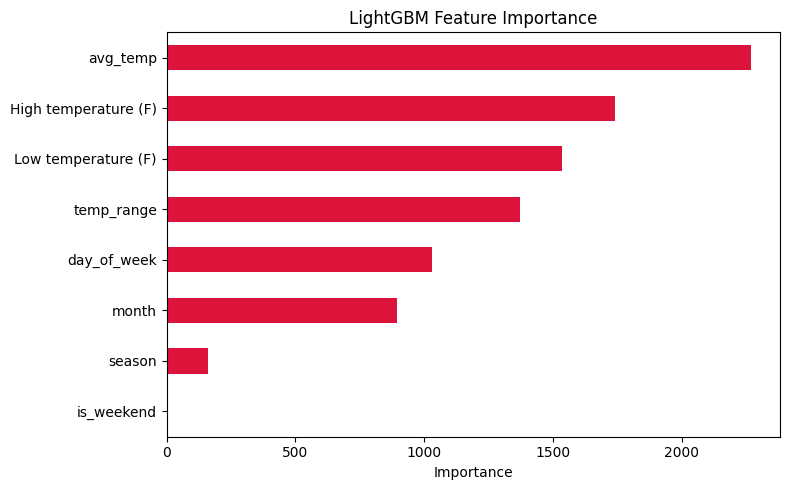

In [29]:
lgb_model = models['LightGBM']
importance = pd.Series(lgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind='barh', ax=ax, color='crimson')
ax.set_title('LightGBM Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [15]:
today = pd.DataFrame([{
    'High temperature (F)': 93,
    'Low temperature (F)':  65,
    'avg_temp':             (93 + 65) / 2,
    'temp_range':           93 - 65,
    'month':                4,
    'day_of_week':          0,  # Monday
    'is_weekend':           0,
    'season':               1,  # Spring
}])

print("Predicted cost for 2026-04-20 (High: 93F, Low: 65F)\n")
for name, model in models.items():
    if model is None:
        pred = y_train.mean()
    elif name in ('Linear Regression', 'Ridge'):
        pred = model.predict(scaler.transform(today))[0]
    else:
        pred = model.predict(today)[0]
    print(f"  {name:<20} ${pred:.2f}")

Predicted cost for 2026-04-20 (High: 93F, Low: 65F)

  Baseline (mean)      $4.39
  Linear Regression    $3.82
  Ridge                $3.82
  Random Forest        $2.17
  LightGBM             $1.72


In [13]:
forecast = pd.DataFrame([
    {'date': '2026-04-20', 'High temperature (F)': 93, 'Low temperature (F)': 65},  # Monday
    {'date': '2026-04-21', 'High temperature (F)': 93, 'Low temperature (F)': 63},  # Tuesday
    {'date': '2026-04-22', 'High temperature (F)': 85, 'Low temperature (F)': 59},  # Wednesday
    {'date': '2026-04-23', 'High temperature (F)': 84, 'Low temperature (F)': 59},  # Thursday
    {'date': '2026-04-24', 'High temperature (F)': 87, 'Low temperature (F)': 58},  # Friday
])

forecast['date']        = pd.to_datetime(forecast['date'])
forecast['avg_temp']    = (forecast['High temperature (F)'] + forecast['Low temperature (F)']) / 2
forecast['temp_range']  = forecast['High temperature (F)'] - forecast['Low temperature (F)']
forecast['month']       = forecast['date'].dt.month
forecast['day_of_week'] = forecast['date'].dt.dayofweek
forecast['is_weekend']  = (forecast['day_of_week'] >= 5).astype(int)
forecast['season']      = 1  # Spring

X_forecast = forecast[FEATURES]

lgb_preds = models['LightGBM'].predict(X_forecast)
forecast['Predicted Cost ($)'] = lgb_preds.round(2)
forecast[['date', 'High temperature (F)', 'Low temperature (F)', 'Predicted Cost ($)']]

,date,High temperature (F),Low temperature (F),Predicted Cost ($)
0,2026-04-20,93,65,1.72
1,2026-04-21,93,63,2.21
2,2026-04-22,85,59,1.60
3,2026-04-23,84,59,1.41
4,2026-04-24,87,58,1.05


In [17]:
forecast = pd.DataFrame([
    {'date': '2026-04-20', 'High temperature (F)': 93, 'Low temperature (F)': 65},  # Monday
    {'date': '2026-04-21', 'High temperature (F)': 93, 'Low temperature (F)': 63},  # Tuesday
    {'date': '2026-04-22', 'High temperature (F)': 85, 'Low temperature (F)': 59},  # Wednesday
    {'date': '2026-04-23', 'High temperature (F)': 84, 'Low temperature (F)': 59},  # Thursday
    {'date': '2026-04-24', 'High temperature (F)': 87, 'Low temperature (F)': 58},  # Friday
])

forecast['date']        = pd.to_datetime(forecast['date'])
forecast['avg_temp']    = (forecast['High temperature (F)'] + forecast['Low temperature (F)']) / 2
forecast['temp_range']  = forecast['High temperature (F)'] - forecast['Low temperature (F)']
forecast['month']       = forecast['date'].dt.month
forecast['day_of_week'] = forecast['date'].dt.dayofweek
forecast['is_weekend']  = (forecast['day_of_week'] >= 5).astype(int)
forecast['season']      = 1  # Spring

X_forecast = forecast[FEATURES]

lgb_preds = models['Random Forest'].predict(X_forecast)
forecast['Predicted Cost ($)'] = lgb_preds.round(2)
forecast[['date', 'High temperature (F)', 'Low temperature (F)', 'Predicted Cost ($)']]

,date,High temperature (F),Low temperature (F),Predicted Cost ($)
0,2026-04-20,93,65,2.17
1,2026-04-21,93,63,2.07
2,2026-04-22,85,59,1.36
3,2026-04-23,84,59,1.50
4,2026-04-24,87,58,1.38


Let's revist at end of week to study the accuracy.